<h2 align="center">CIFAR10 Classification</h2>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
import numpy as np

In [ ]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Data Load

[CIFAR-10- torchvision](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html)

In [ ]:
from torchvision.datasets.utils import download_and_extract_archive

# Download the CIFAR-10 archive from an alternative server
download_and_extract_archive(
    url="https://zenodo.org/records/10089977/files/cifar-10-python.tar.gz",
    download_root="./data",
    filename="cifar-10-python.tar.gz",
    md5="c58f30108f718f92721af3b95e74349a",
)

100%|██████████| 170M/170M [01:46<00:00, 1.60MB/s]


In [ ]:
# Transformations
transform = transforms.Compose([
    transforms.ToTensor(), # 0-1
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))   # (R,G,B) mean=0.5 , std=0.5
])

# CIFAR-10 dataset
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

In [ ]:
len(train_dataset), len(test_dataset)

(50000, 10000)

In [ ]:
batch_size = 100

# Data loaders
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

### Visualize a Few Images

In [ ]:
for i, (images, labels) in enumerate(train_loader):
    print(images.shape)
    print(labels.shape)
    break

torch.Size([100, 3, 32, 32])
torch.Size([100])


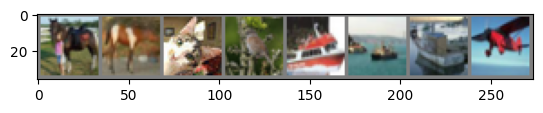

In [ ]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0))) #(H,W,C)
    plt.show()

# show images
imshow(torchvision.utils.make_grid(images[:8]))

In [ ]:
labels[:8]

tensor([7, 7, 3, 2, 8, 8, 8, 0])

In [ ]:
classes = train_dataset.classes
classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [ ]:
[classes[i] for i in labels[:8]]

['horse', 'horse', 'cat', 'bird', 'ship', 'ship', 'ship', 'airplane']

### Train a Neural Network

### CNN architecture

![CIFAR-10 CNN architecture](https://raw.githubusercontent.com/sparshbansal-newton/images-used/main/cnn/cifar10_cnn.png)

### 🧱 CNN layers at a glance

| Layer | Output shape |
|---|---|
| Input | (3, 32, 32) |
| `Conv2d(3→32, 3×3, same)` → `ReLU` → `MaxPool(2×2)` | (32, 16, 16) |
| `Conv2d(32→64, 3×3)` → `ReLU` → `MaxPool(2×2)` | (64, 7, 7) |
| `Flatten` | 3136 |
| `Linear(3136→600)` → `ReLU` → `Linear(600→120)` → `ReLU` | 120 |
| `Linear(120→10)` | 10 |

Conv output size: `(in − kernel + 2·padding) / stride + 1`

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=(3,3), padding='same'),  # Output: (32, 32, 32)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)),        # Output: (32, 16, 16)

            nn.Conv2d(32, 64, kernel_size=(3,3)),             # Output: (64, 14, 14)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2))         # Output: (64, 7, 7)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),                                # Flatten to (64 * 7 * 7 = 3136)
            nn.Linear(64 * 7 * 7, 600),                  # Corrected input size
            nn.ReLU(),
            nn.Linear(600, 120),
            nn.ReLU(),
            nn.Linear(120, 10)
        )

    def forward(self, x):
        x = self.network(x)
        x = self.fc_layers(x)
        return x

In [ ]:
model = CNN()
dummy_input = torch.randn(1, 3, 32, 32)  # Single example with CIFAR-10 dimensions
output = model(dummy_input)
print("Output shape:", output.shape)  # Should be [1, 10]

Output shape: torch.Size([1, 10])


In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary

summary(model, input_size=(1, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 10]                   --
├─Sequential: 1-1                        [1, 64, 7, 7]             --
│    └─Conv2d: 2-1                       [1, 32, 32, 32]           896
│    └─ReLU: 2-2                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-3                    [1, 32, 16, 16]           --
│    └─Conv2d: 2-4                       [1, 64, 14, 14]           18,496
│    └─ReLU: 2-5                         [1, 64, 14, 14]           --
│    └─MaxPool2d: 2-6                    [1, 64, 7, 7]             --
├─Sequential: 1-2                        [1, 10]                   --
│    └─Flatten: 2-7                      [1, 3136]                 --
│    └─Linear: 2-8                       [1, 600]                  1,882,200
│    └─ReLU: 2-9                         [1, 600]                  --
│    └─Linear: 2-10                      [1, 120]                  72,120

In [ ]:
# Hyperparameters
num_epochs = 10
learning_rate = 0.001

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
# Training loop
total_step = len(train_loader)
for epoch in range(num_epochs):
    model.train()
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{total_step}], Loss: {loss.item():.4f}")

# Testing the model (on train and test data)
model.eval()
acc = {}
with torch.no_grad():
    for name, loader in [('train', train_loader), ('test', test_loader)]:
        correct = 0
        total = 0
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            predicted = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        acc[name] = 100 * correct / total

baseline_train_acc, baseline_test_acc = acc['train'], acc['test']
print(f"Train accuracy: {baseline_train_acc:.2f}%")
print(f"Accuracy of the model on the 10000 test images: {baseline_test_acc:.2f}%")

Epoch [1/10], Step [100/500], Loss: 1.3800
Epoch [1/10], Step [200/500], Loss: 1.4684
Epoch [1/10], Step [300/500], Loss: 1.4865
Epoch [1/10], Step [400/500], Loss: 1.2473
Epoch [1/10], Step [500/500], Loss: 1.1534
Epoch [2/10], Step [100/500], Loss: 1.0262
Epoch [2/10], Step [200/500], Loss: 0.9652
Epoch [2/10], Step [300/500], Loss: 0.8880
Epoch [2/10], Step [400/500], Loss: 0.8706
Epoch [2/10], Step [500/500], Loss: 0.9212
Epoch [3/10], Step [100/500], Loss: 1.0797
Epoch [3/10], Step [200/500], Loss: 0.8837
Epoch [3/10], Step [300/500], Loss: 0.6368
Epoch [3/10], Step [400/500], Loss: 0.8586
Epoch [3/10], Step [500/500], Loss: 0.6415
Epoch [4/10], Step [100/500], Loss: 0.7011
Epoch [4/10], Step [200/500], Loss: 0.5967
Epoch [4/10], Step [300/500], Loss: 0.6277
Epoch [4/10], Step [400/500], Loss: 0.5696
Epoch [4/10], Step [500/500], Loss: 0.5526
Epoch [5/10], Step [100/500], Loss: 0.4292
Epoch [5/10], Step [200/500], Loss: 0.5603
Epoch [5/10], Step [300/500], Loss: 0.5081
Epoch [5/10

---
## 🧩 Add BatchNorm & Dropout

Same CNN, two new layers (neither changes the shape):
- **`BatchNorm2d(C)`** → after each `Conv2d` (`C` = its output channels)
- **`Dropout(p)`** → after `ReLU` in the FC block

In [ ]:
class CNN_BN_Dropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            # ---- Block 1 ----
            nn.Conv2d(3, 32, kernel_size=(3,3), padding='same'),  # Output: (32, 32, 32)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)),        # Output: (32, 16, 16)

            # ---- Block 2 ----
            nn.Conv2d(32, 64, kernel_size=(3,3)),                 # Output: (64, 14, 14)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)),        # Output: (64, 7, 7)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),                                         # 3136
            nn.Linear(64 * 7 * 7, 600),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(600, 120),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(120, 10)                                    # output layer: no ReLU / Dropout
        )

    def forward(self, x):
        x = self.network(x)
        x = self.fc_layers(x)
        return x

In [ ]:
model2 = CNN_BN_Dropout()
model2.eval()
output = model2(torch.randn(1, 3, 32, 32))
print("Output shape:", output.shape)  # Should be [1, 10]

Output shape: torch.Size([1, 10])


### 🔍 Layer-by-layer view

In [ ]:
from torchinfo import summary

summary(model2, input_size=(1, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
CNN_BN_Dropout                           [1, 10]                   --
├─Sequential: 1-1                        [1, 64, 7, 7]             --
│    └─Conv2d: 2-1                       [1, 32, 32, 32]           896
│    └─BatchNorm2d: 2-2                  [1, 32, 32, 32]           64
│    └─ReLU: 2-3                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-4                    [1, 32, 16, 16]           --
│    └─Conv2d: 2-5                       [1, 64, 14, 14]           18,496
│    └─BatchNorm2d: 2-6                  [1, 64, 14, 14]           128
│    └─ReLU: 2-7                         [1, 64, 14, 14]           --
│    └─MaxPool2d: 2-8                    [1, 64, 7, 7]             --
├─Sequential: 1-2                        [1, 10]                   --
│    └─Flatten: 2-9                      [1, 3136]                 --
│    └─Linear: 2-10                      [1, 600]                  1,882,200
│ 

### Train & test

In [ ]:
# Hyperparameters
num_epochs = 10
learning_rate = 0.001

model2 = CNN_BN_Dropout().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=learning_rate)

# Training loop
total_step = len(train_loader)
for epoch in range(num_epochs):
    model2.train()   # Dropout ON, BatchNorm uses batch statistics
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model2(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{total_step}], Loss: {loss.item():.4f}")

# Testing the model (on train and test data)
model2.eval()        # Dropout OFF, BatchNorm uses running statistics
acc = {}
with torch.no_grad():
    for name, loader in [('train', train_loader), ('test', test_loader)]:
        correct = 0
        total = 0
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model2(images)
            predicted = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        acc[name] = 100 * correct / total

reg_train_acc, reg_test_acc = acc['train'], acc['test']
print(f"Train accuracy: {reg_train_acc:.2f}%")
print(f"Accuracy of the model on the 10000 test images: {reg_test_acc:.2f}%")

Epoch [1/10], Step [100/500], Loss: 1.7527
Epoch [1/10], Step [200/500], Loss: 1.5823
Epoch [1/10], Step [300/500], Loss: 1.6463
Epoch [1/10], Step [400/500], Loss: 1.5071
Epoch [1/10], Step [500/500], Loss: 1.4952
Epoch [2/10], Step [100/500], Loss: 1.4218
Epoch [2/10], Step [200/500], Loss: 1.1943
Epoch [2/10], Step [300/500], Loss: 1.4096
Epoch [2/10], Step [400/500], Loss: 1.2163
Epoch [2/10], Step [500/500], Loss: 1.2943
Epoch [3/10], Step [100/500], Loss: 1.2789
Epoch [3/10], Step [200/500], Loss: 1.1002
Epoch [3/10], Step [300/500], Loss: 1.0763
Epoch [3/10], Step [400/500], Loss: 0.8897
Epoch [3/10], Step [500/500], Loss: 1.0802
Epoch [4/10], Step [100/500], Loss: 0.9158
Epoch [4/10], Step [200/500], Loss: 1.1532
Epoch [4/10], Step [300/500], Loss: 0.7895
Epoch [4/10], Step [400/500], Loss: 0.9088
Epoch [4/10], Step [500/500], Loss: 0.9666
Epoch [5/10], Step [100/500], Loss: 0.9080
Epoch [5/10], Step [200/500], Loss: 0.9894
Epoch [5/10], Step [300/500], Loss: 1.0826
Epoch [5/10

### Comparison

                    Train Acc  Test Acc
CNN                     97.73     71.94
CNN + BN + Dropout      83.31     75.45


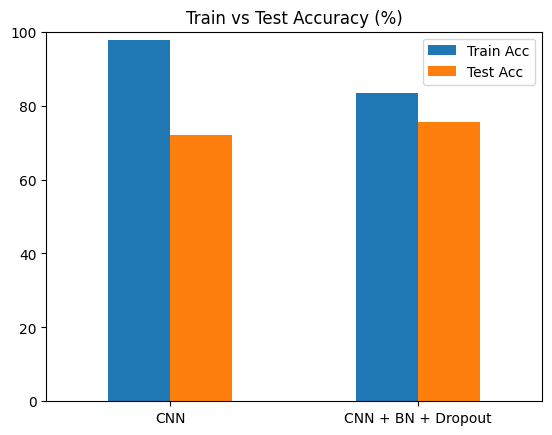

In [ ]:
import pandas as pd

results = pd.DataFrame({
    'Train Acc': [baseline_train_acc, reg_train_acc],
    'Test Acc':  [baseline_test_acc,  reg_test_acc],
}, index=['CNN', 'CNN + BN + Dropout'])

print(results.round(2))
results.plot.bar(rot=0, ylim=(0, 100), title='Train vs Test Accuracy (%)')
plt.show()

### ✅ Conclusion
- CNN = **conv feature extractor** (19K params) + **FC classifier** (1.96M params, ≈ 99%).
- **BatchNorm2d** after each conv → stable, faster training; adds very few params.
- **Dropout** in the FC block → where most params live; no params, no shape change.
- Result: higher test accuracy, smaller train–test gap. `model.eval()` turns Dropout off at test time.